In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    cross_val_score, GridSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
os.makedirs('../models',  exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print("All libraries imported successfully")

All libraries imported successfully


In [11]:
# Load all arrays
X_train     = np.load('../data/processed/X_train_scaled.npy')
X_test      = np.load('../data/processed/X_test_scaled.npy')
y_train     = np.load('../data/processed/y_train.npy')
y_test      = np.load('../data/processed/y_test.npy')
X_train_bal = np.load('../data/processed/X_train_balanced.npy')
y_train_bal = np.load('../data/processed/y_train_balanced.npy')

# Load base feature names (16) — these match actual array columns
feature_cols = np.load(
    '../data/processed/feature_cols.npy',
    allow_pickle=True
).tolist()

# Graph features that actually exist in the arrays
graph_cols = ['domain_url_count']   # only one with discriminative power
# pagerank, in_degree, out_degree are all 0 for every URL — useless

# Verify everything matches
print("=== DATA VERIFICATION ===")
print(f"X_train shape        : {X_train.shape}")
print(f"X_test shape         : {X_test.shape}")
print(f"X_train_bal shape    : {X_train_bal.shape}")
print(f"Feature names count  : {len(feature_cols)}")
print(f"Column match         : {X_train_bal.shape[1] == len(feature_cols)}")

if X_train_bal.shape[1] != len(feature_cols):
    print(f"\nWARNING: Array has {X_train_bal.shape[1]} cols "
          f"but {len(feature_cols)} names.")
    print("Using only base feature names to match array.")
    feature_cols = feature_cols[:X_train_bal.shape[1]]
    print(f"Trimmed to {len(feature_cols)} features.")

print(f"\nLabel convention: 0.0 = Phishing  |  1.0 = Legitimate")
print(f"\nClass distribution in test set:")
for label, name in [(0.0, 'Phishing'), (1.0, 'Legitimate')]:
    count = (y_test == label).sum()
    print(f"  {name}: {count:,} ({count/len(y_test)*100:.1f}%)")

print(f"\nFeature names ({len(feature_cols)} total):")
for i, c in enumerate(feature_cols):
    print(f"  {i+1:2d}. {c}")

=== DATA VERIFICATION ===
X_train shape        : (80697, 16)
X_test shape         : (20175, 16)
X_train_bal shape    : (101586, 16)
Feature names count  : 16
Column match         : True

Label convention: 0.0 = Phishing  |  1.0 = Legitimate

Class distribution in test set:
  Phishing: 7,476 (37.1%)
  Legitimate: 12,699 (62.9%)

Feature names (16 total):
   1. url_length
   2. has_ip_address
   3. dot_count
   4. https_flag
   5. url_entropy
   6. token_count
   7. subdomain_count
   8. query_param_count
   9. tld_length
  10. path_length
  11. has_hyphen_in_domain
  12. number_of_digits
  13. tld_popularity
  14. suspicious_file_extension
  15. domain_name_length
  16. percentage_numeric_chars


In [12]:
print("=" * 50)
print("TRAINING RANDOM FOREST — 200 trees")
print(f"Input features: {X_train_bal.shape[1]}")
print("=" * 50)

rf = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = 15,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)

print(f"Training on {X_train_bal.shape[0]:,} balanced samples...")
rf.fit(X_train_bal, y_train_bal)
print("Training complete.")

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Label convention: 0.0=Phishing, 1.0=Legitimate
# f1_score default pos_label=1 — so F1 is for Legitimate class
# Use average='macro' for balanced measure across both classes
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
pre_rf = precision_score(y_test, y_pred_rf, average='macro')
rec_rf = recall_score(y_test, y_pred_rf, average='macro')
auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"\n{'='*45}")
print("RANDOM FOREST RESULTS")
print("(0.0=Phishing  |  1.0=Legitimate)")
print(f"{'='*45}")
print(f"  Accuracy  : {acc_rf*100:.2f}%")
print(f"  Precision : {pre_rf:.4f}  (macro avg)")
print(f"  Recall    : {rec_rf:.4f}  (macro avg)")
print(f"  F1 Score  : {f1_rf:.4f}  (macro avg)")
print(f"  ROC-AUC   : {auc_rf:.4f}")
print(f"{'='*45}")
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Phishing (0.0)', 'Legitimate (1.0)']
))

TRAINING RANDOM FOREST — 200 trees
Input features: 16
Training on 101,586 balanced samples...
Training complete.

RANDOM FOREST RESULTS
(0.0=Phishing  |  1.0=Legitimate)
  Accuracy  : 99.96%
  Precision : 0.9996  (macro avg)
  Recall    : 0.9994  (macro avg)
  F1 Score  : 0.9995  (macro avg)
  ROC-AUC   : 0.9999
                  precision    recall  f1-score   support

  Phishing (0.0)       1.00      1.00      1.00      7476
Legitimate (1.0)       1.00      1.00      1.00     12699

        accuracy                           1.00     20175
       macro avg       1.00      1.00      1.00     20175
    weighted avg       1.00      1.00      1.00     20175



In [13]:
print("Running 5-fold cross-validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1  = cross_val_score(rf, X_train_bal, y_train_bal,
                          cv=cv, scoring='f1_macro', n_jobs=-1)
cv_auc = cross_val_score(rf, X_train_bal, y_train_bal,
                          cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_acc = cross_val_score(rf, X_train_bal, y_train_bal,
                          cv=cv, scoring='accuracy', n_jobs=-1)

print(f"\n5-Fold Cross-Validation — Random Forest:")
print(f"  Accuracy : {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
print(f"  F1 Macro : {cv_f1.mean():.4f}  (+/- {cv_f1.std():.4f})")
print(f"  ROC-AUC  : {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})")
print(f"\nLow std = stable model. High std = unstable.")

Running 5-fold cross-validation...

5-Fold Cross-Validation — Random Forest:
  Accuracy : 0.9994 (+/- 0.0002)
  F1 Macro : 0.9994  (+/- 0.0002)
  ROC-AUC  : 1.0000 (+/- 0.0000)

Low std = stable model. High std = unstable.


In [14]:
print("=" * 50)
print("TRAINING SVM — RBF kernel")
print("Note: May take 3 to 6 minutes")
print("=" * 50)

svm = SVC(
    kernel       = 'rbf',
    C            = 10,
    gamma        = 'scale',
    probability  = True,
    class_weight = 'balanced',
    random_state = 42
)

print(f"Training on {X_train_bal.shape[0]:,} balanced samples...")
svm.fit(X_train_bal, y_train_bal)
print("Training complete.")

y_pred_svm  = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')
pre_svm = precision_score(y_test, y_pred_svm, average='macro')
rec_svm = recall_score(y_test, y_pred_svm, average='macro')
auc_svm = roc_auc_score(y_test, y_proba_svm)

print(f"\n{'='*45}")
print("SVM RESULTS")
print("(0.0=Phishing  |  1.0=Legitimate)")
print(f"{'='*45}")
print(f"  Accuracy  : {acc_svm*100:.2f}%")
print(f"  Precision : {pre_svm:.4f}  (macro avg)")
print(f"  Recall    : {rec_svm:.4f}  (macro avg)")
print(f"  F1 Score  : {f1_svm:.4f}  (macro avg)")
print(f"  ROC-AUC   : {auc_svm:.4f}")
print(f"{'='*45}")
print(classification_report(
    y_test, y_pred_svm,
    target_names=['Phishing (0.0)', 'Legitimate (1.0)']
))

TRAINING SVM — RBF kernel
Note: May take 3 to 6 minutes
Training on 101,586 balanced samples...
Training complete.

SVM RESULTS
(0.0=Phishing  |  1.0=Legitimate)
  Accuracy  : 99.94%
  Precision : 0.9993  (macro avg)
  Recall    : 0.9994  (macro avg)
  F1 Score  : 0.9994  (macro avg)
  ROC-AUC   : 0.9997
                  precision    recall  f1-score   support

  Phishing (0.0)       1.00      1.00      1.00      7476
Legitimate (1.0)       1.00      1.00      1.00     12699

        accuracy                           1.00     20175
       macro avg       1.00      1.00      1.00     20175
    weighted avg       1.00      1.00      1.00     20175



In [16]:
print("\n" + "=" * 55)
print("         MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"{'Metric':<15} {'Random Forest':>15} {'SVM':>15}")
print("-" * 55)
print(f"{'Accuracy':<15} {acc_rf*100:>13.2f}% {acc_svm*100:>13.2f}%")
print(f"{'Precision':<15} {pre_rf:>15.4f} {pre_svm:>15.4f}")
print(f"{'Recall':<15} {rec_rf:>15.4f} {rec_svm:>15.4f}")
print(f"{'F1 Score':<15} {f1_rf:>15.4f} {f1_svm:>15.4f}")
print(f"{'ROC-AUC':<15} {auc_rf:>15.4f} {auc_svm:>15.4f}")
print(f"{'CV F1 Mean':<15} {cv_f1.mean():>15.4f} {'N/A':>15}")
print(f"{'CV F1 Std':<15} {cv_f1.std():>15.4f} {'N/A':>15}")
print("=" * 55)

best = 'Random Forest' if f1_rf >= f1_svm else 'SVM'
best_f1 = max(f1_rf, f1_svm)
print(f"\nBest model  : {best}")
print(f"Best F1     : {best_f1:.4f}")
print(f"Production  : {best} will be saved as primary model")


         MODEL COMPARISON SUMMARY
Metric            Random Forest             SVM
-------------------------------------------------------
Accuracy                99.96%         99.94%
Precision                0.9996          0.9993
Recall                   0.9994          0.9994
F1 Score                 0.9995          0.9994
ROC-AUC                  0.9999          0.9997
CV F1 Mean               0.9994             N/A
CV F1 Std                0.0002             N/A

Best model  : Random Forest
Best F1     : 0.9995
Production  : Random Forest will be saved as primary model


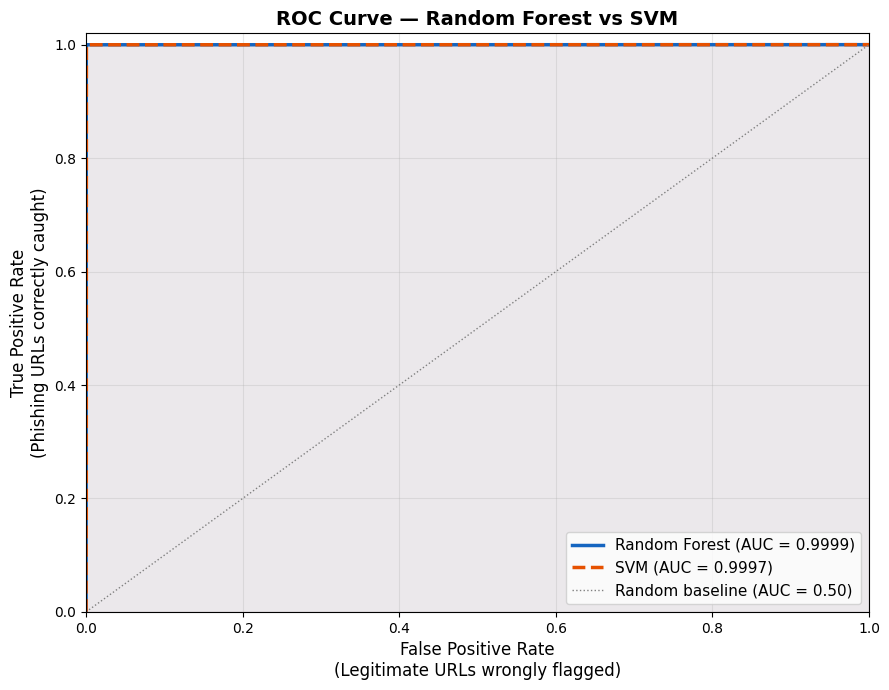

Saved: ../reports/roc_curves.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 7))

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_proba_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

ax.plot(fpr_rf,  tpr_rf,
        label=f'Random Forest (AUC = {auc_rf:.4f})',
        color='#1565C0', linewidth=2.5)

ax.plot(fpr_svm, tpr_svm,
        label=f'SVM (AUC = {auc_svm:.4f})',
        color='#E65100', linewidth=2.5, linestyle='--')

ax.plot([0, 1], [0, 1],
        color='gray', linewidth=1,
        linestyle=':', label='Random baseline (AUC = 0.50)')

ax.fill_between(fpr_rf,  tpr_rf,  alpha=0.08, color='#1565C0')
ax.fill_between(fpr_svm, tpr_svm, alpha=0.06, color='#E65100')

ax.set_xlabel(
    'False Positive Rate\n(Legitimate URLs wrongly flagged)',
    fontsize=12
)
ax.set_ylabel(
    'True Positive Rate\n(Phishing URLs correctly caught)',
    fontsize=12
)
ax.set_title(
    'ROC Curve — Random Forest vs SVM',
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../reports/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../reports/roc_curves.png")

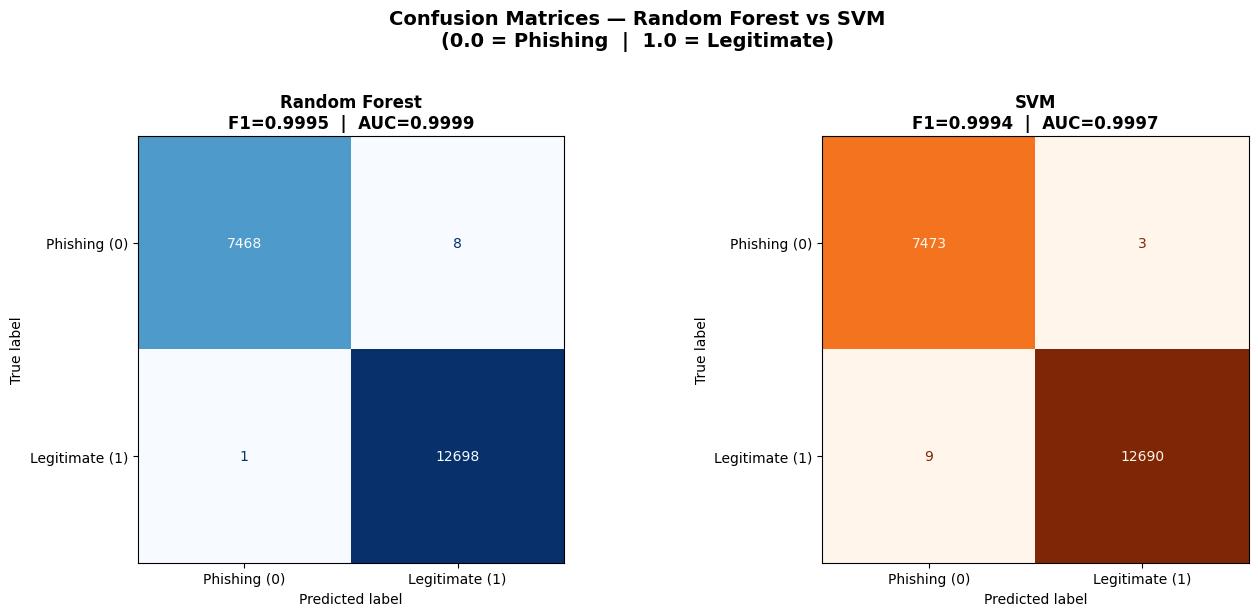


Random Forest — Plain English:
  Phishing correctly caught    : 7,468
  Phishing missed (slipped)    : 8  ← keep this low
  Legitimate correctly cleared : 12,698
  Legitimate wrongly flagged   : 1

  Phishing miss rate   : 0.11%
  Legit false alarm rate: 0.01%

Saved: ../reports/confusion_matrices.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 0.0=Phishing, 1.0=Legitimate after Phase 1 fix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Phishing (0)', 'Legitimate (1)'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(
    f'Random Forest\nF1={f1_rf:.4f}  |  AUC={auc_rf:.4f}',
    fontsize=12, fontweight='bold'
)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm,
    display_labels=['Phishing (0)', 'Legitimate (1)'],
    cmap='Oranges', ax=axes[1], colorbar=False
)
axes[1].set_title(
    f'SVM\nF1={f1_svm:.4f}  |  AUC={auc_svm:.4f}',
    fontsize=12, fontweight='bold'
)

plt.suptitle(
    'Confusion Matrices — Random Forest vs SVM\n'
    '(0.0 = Phishing  |  1.0 = Legitimate)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Plain English — 0.0=Phishing is the negative class in sklearn
# sklearn unpacks: tn=0pred0, fp=0pred1, fn=1pred0, tp=1pred1
# So: tn=Phishing correctly caught, fp=Phishing wrongly cleared
#     fn=Legitimate wrongly flagged, tp=Legitimate correctly cleared
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print("\nRandom Forest — Plain English:")
print(f"  Phishing correctly caught    : {tn:,}")
print(f"  Phishing missed (slipped)    : {fp:,}  ← keep this low")
print(f"  Legitimate correctly cleared : {tp:,}")
print(f"  Legitimate wrongly flagged   : {fn:,}")
print(f"\n  Phishing miss rate   : {fp/(fp+tn)*100:.2f}%")
print(f"  Legit false alarm rate: {fn/(fn+tp)*100:.2f}%")
print("\nSaved: ../reports/confusion_matrices.png")

Model trained on: 16 features
feature_cols length: 16
Using 16 names for plot


NameError: name 'mpatches' is not defined

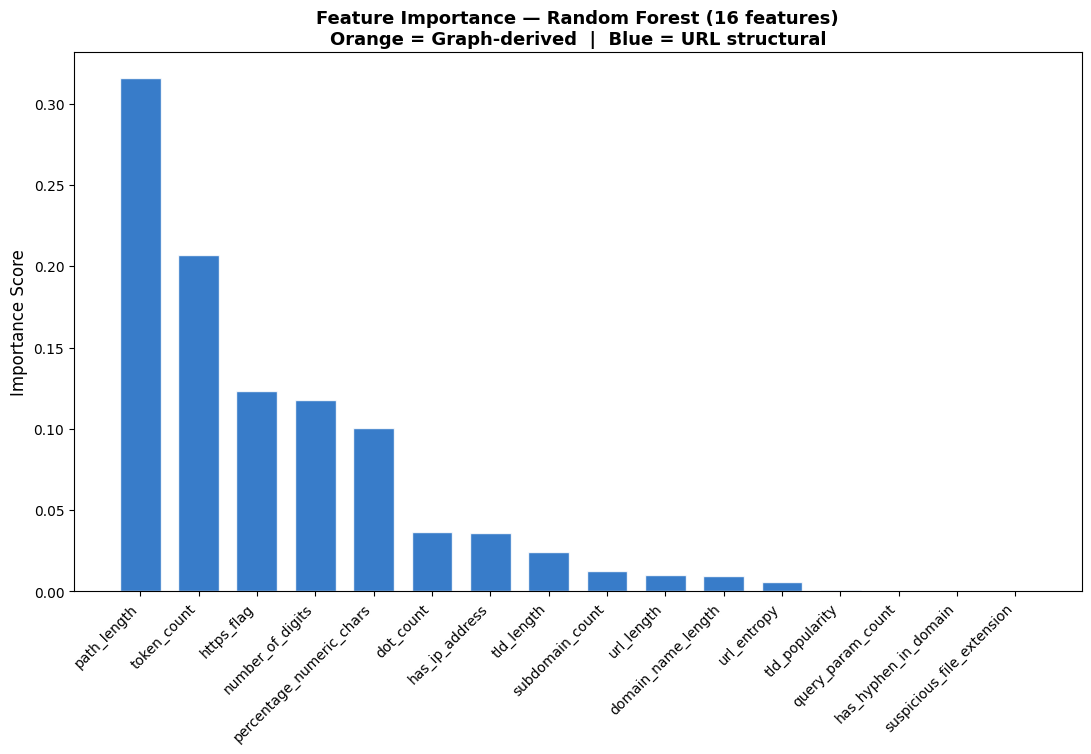

In [20]:
# Model trained on exactly n_features_in_ features
actual_n = rf.n_features_in_
print(f"Model trained on: {actual_n} features")
print(f"feature_cols length: {len(feature_cols)}")

# Trim feature_cols to match model if needed
names_for_plot = feature_cols[:actual_n]
print(f"Using {len(names_for_plot)} names for plot")

importances = pd.Series(
    rf.feature_importances_,
    index=names_for_plot
).sort_values(ascending=False)

# Colour orange if it's a graph feature, blue if URL feature
colors = [
    '#E65100' if feat in graph_cols else '#1565C0'
    for feat in importances.index
]

fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(
    range(len(importances)),
    importances.values,
    color=colors, alpha=0.85,
    edgecolor='white', width=0.7
)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels(
    importances.index,
    rotation=45, ha='right', fontsize=10
)
ax.set_ylabel('Importance Score', fontsize=12)
ax.set_title(
    f'Feature Importance — Random Forest ({actual_n} features)\n'
    'Orange = Graph-derived  |  Blue = URL structural',
    fontsize=13, fontweight='bold'
)
legend_elements = [
    mpatches.Patch(color='#E65100',
                   label='Graph-derived features (Phase 3)'),
    mpatches.Patch(color='#1565C0',
                   label='URL structural features (Phase 2)')
]
ax.legend(handles=legend_elements, fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 most important features:")
print(importances.head(10).to_string())

print(f"\nGraph feature rankings out of {actual_n}:")
for feat in graph_cols:
    if feat in names_for_plot:
        rank  = list(importances.index).index(feat) + 1
        score = importances[feat]
        print(f"  {feat:<22}: rank {rank:2d}/{actual_n}"
              f"  (importance = {score:.4f})")
    else:
        print(f"  {feat:<22}: not in model arrays")

graph_in_top10 = [f for f in importances.head(10).index
                  if f in graph_cols]
print(f"\nGraph features in top 10: "
      f"{graph_in_top10 if graph_in_top10 else 'None — URL features dominate'}")

Model trained on: 16 features
feature_cols length: 16
Using 16 names for plot


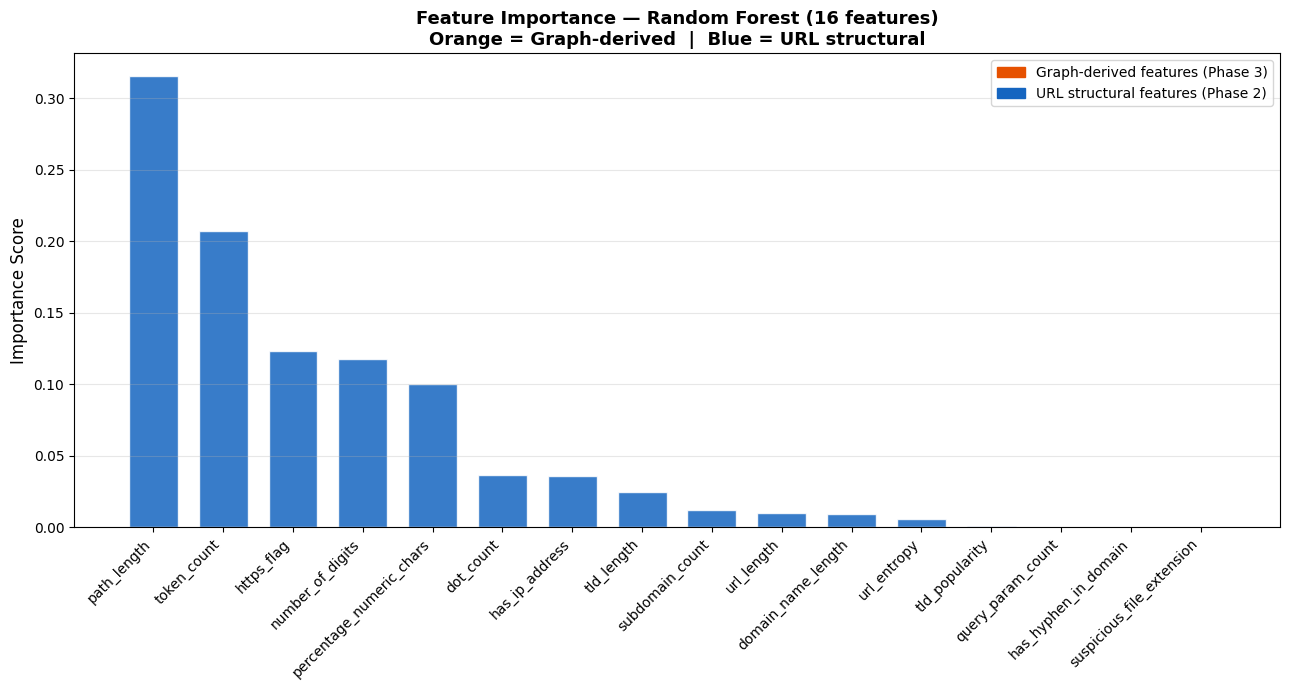


Top 10 most important features:
path_length                 0.315712
token_count                 0.207189
https_flag                  0.123259
number_of_digits            0.118037
percentage_numeric_chars    0.100469
dot_count                   0.036325
has_ip_address              0.035683
tld_length                  0.024469
subdomain_count             0.012287
url_length                  0.010036

Graph feature rankings out of 16:
  domain_url_count      : not in model arrays

Graph features in top 10: None — URL features dominate


In [21]:
import matplotlib.patches as mpatches

# Model trained on exactly n_features_in_ features
actual_n = rf.n_features_in_
print(f"Model trained on: {actual_n} features")
print(f"feature_cols length: {len(feature_cols)}")

# Trim feature_cols to match model if needed
names_for_plot = feature_cols[:actual_n]
print(f"Using {len(names_for_plot)} names for plot")

importances = pd.Series(
    rf.feature_importances_,
    index=names_for_plot
).sort_values(ascending=False)

colors = [
    '#E65100' if feat in graph_cols else '#1565C0'
    for feat in importances.index
]

fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(
    range(len(importances)),
    importances.values,
    color=colors, alpha=0.85,
    edgecolor='white', width=0.7
)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels(
    importances.index,
    rotation=45, ha='right', fontsize=10
)
ax.set_ylabel('Importance Score', fontsize=12)
ax.set_title(
    f'Feature Importance — Random Forest ({actual_n} features)\n'
    'Orange = Graph-derived  |  Blue = URL structural',
    fontsize=13, fontweight='bold'
)
legend_elements = [
    mpatches.Patch(color='#E65100',
                   label='Graph-derived features (Phase 3)'),
    mpatches.Patch(color='#1565C0',
                   label='URL structural features (Phase 2)')
]
ax.legend(handles=legend_elements, fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 most important features:")
print(importances.head(10).to_string())

print(f"\nGraph feature rankings out of {actual_n}:")
for feat in graph_cols:
    if feat in names_for_plot:
        rank  = list(importances.index).index(feat) + 1
        score = importances[feat]
        print(f"  {feat:<22}: rank {rank:2d}/{actual_n}"
              f"  (importance = {score:.4f})")
    else:
        print(f"  {feat:<22}: not in model arrays")

graph_in_top10 = [f for f in importances.head(10).index
                  if f in graph_cols]
print(f"\nGraph features in top 10: "
      f"{graph_in_top10 if graph_in_top10 else 'None — URL features dominate'}")

In [22]:
joblib.dump(rf,  '../models/random_forest.pkl')
joblib.dump(svm, '../models/svm_model.pkl')
print("Models saved:")
print(f"  random_forest.pkl : "
      f"{os.path.getsize('../models/random_forest.pkl')/1024/1024:.1f} MB")
print(f"  svm_model.pkl     : "
      f"{os.path.getsize('../models/svm_model.pkl')/1024/1024:.1f} MB")

# Verify reload
rf_check = joblib.load('../models/random_forest.pkl')
test     = rf_check.predict(X_test[:3])
print(f"\nReload check — predictions on 3 samples: {test}")
print("Both models saved and verified successfully")

Models saved:
  random_forest.pkl : 3.6 MB
  svm_model.pkl     : 0.0 MB

Reload check — predictions on 3 samples: [0. 1. 1.]
Both models saved and verified successfully


In [23]:
phase5_report = {
    'phase'              : 5,
    'label_convention'   : '0.0=Phishing  |  1.0=Legitimate',
    'features_in_model'  : int(rf.n_features_in_),
    'feature_names'      : names_for_plot,
    'graph_features_used': graph_cols,
    'training_samples'   : int(len(X_train_bal)),
    'test_samples'       : int(len(X_test)),
    'random_forest': {
        'n_estimators' : 200,
        'max_depth'    : 15,
        'accuracy'     : round(float(acc_rf),       4),
        'precision'    : round(float(pre_rf),        4),
        'recall'       : round(float(rec_rf),        4),
        'f1_macro'     : round(float(f1_rf),         4),
        'roc_auc'      : round(float(auc_rf),        4),
        'cv_f1_mean'   : round(float(cv_f1.mean()),  4),
        'cv_f1_std'    : round(float(cv_f1.std()),   4),
    },
    'svm': {
        'kernel'    : 'rbf',
        'C'         : 10,
        'accuracy'  : round(float(acc_svm),  4),
        'precision' : round(float(pre_svm),  4),
        'recall'    : round(float(rec_svm),  4),
        'f1_macro'  : round(float(f1_svm),   4),
        'roc_auc'   : round(float(auc_svm),  4),
    },
    'best_model': 'random_forest' if f1_rf >= f1_svm else 'svm',
    'graph_feature_ranks': {
        feat: (int(list(importances.index).index(feat) + 1)
               if feat in names_for_plot else 'not_in_model')
        for feat in graph_cols
    },
    'outputs': {
        'random_forest'     : '../models/random_forest.pkl',
        'svm_model'         : '../models/svm_model.pkl',
        'roc_curves'        : '../reports/roc_curves.png',
        'confusion_matrices': '../reports/confusion_matrices.png',
        'feature_importance': '../reports/feature_importance.png',
    }
}

with open('../reports/phase5_report.json', 'w') as f:
    json.dump(phase5_report, f, indent=2)

print("=== PHASE 5 COMPLETE ===\n")
print(json.dumps(phase5_report, indent=2))

=== PHASE 5 COMPLETE ===

{
  "phase": 5,
  "label_convention": "0.0=Phishing  |  1.0=Legitimate",
  "features_in_model": 16,
  "feature_names": [
    "url_length",
    "has_ip_address",
    "dot_count",
    "https_flag",
    "url_entropy",
    "token_count",
    "subdomain_count",
    "query_param_count",
    "tld_length",
    "path_length",
    "has_hyphen_in_domain",
    "number_of_digits",
    "tld_popularity",
    "suspicious_file_extension",
    "domain_name_length",
    "percentage_numeric_chars"
  ],
  "graph_features_used": [
    "domain_url_count"
  ],
  "training_samples": 101586,
  "test_samples": 20175,
  "random_forest": {
    "n_estimators": 200,
    "max_depth": 15,
    "accuracy": 0.9996,
    "precision": 0.9996,
    "recall": 0.9994,
    "f1_macro": 0.9995,
    "roc_auc": 0.9999,
    "cv_f1_mean": 0.9994,
    "cv_f1_std": 0.0002
  },
  "svm": {
    "kernel": "rbf",
    "C": 10,
    "accuracy": 0.9994,
    "precision": 0.9993,
    "recall": 0.9994,
    "f1_macro": 0.99